# Correlazioni dinamiche del trimero a catena — misura via circuito, tutte le 81 combinazioni

Mirror di `circuito_correlazioni_trimero_anello_tutte.ipynb`, preparazione esatta
(`prepare_state`). Punto di lavoro: $J=1, b=b_c=3.0, D=0.15$.

## 0. Setup

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

from trimer_chain_exact import trimer_hamiltonian_dm
from circuito_correlazioni_trimero_catena import ground_state, correlator_from_circuit
from validate_circuito_correlazioni_catena import classical_exact

J, b, D = 1.0, 3.0, 0.15
H = trimer_hamiltonian_dm(J, b, D).to_matrix()
psi0, E = ground_state(J, b, D)

sites = (1, 2, 3)
comps = ('x', 'y', 'z')
labels = [f"{i}{a}" for i in sites for a in comps]
print(f"Punto: J={J}, b={b}, D={D}  |  E0={E[0]:.6f}, gap={E[1]-E[0]:.6f}")

Punto: J=1.0, b=3.0, D=0.15  |  E0=-7.369247, gap=0.734742


## 1. Misura diretta di tutte le 81 combinazioni ($t=1.3$, $N=200$)

In [2]:
t_fix = 1.3
N = 200
rows = []
for i, al in itertools.product(sites, comps):
    for j, be in itertools.product(sites, comps):
        c_ref = classical_exact(i, al, j, be, t_fix, J, b, D, psi0, H)
        c_sv = correlator_from_circuit(i, al, j, be, t_fix, N, J, b, D, psi0)
        rows.append(dict(i=i, al=al, j=j, be=be, c_ref=c_ref, c_sv=c_sv,
                          residuo=abs(c_ref - c_sv)))

import pandas as pd
df = pd.DataFrame(rows)
print(f"combinazioni misurate: {len(df)}")
df.head()

combinazioni misurate: 81


,i,al,j,be,c_ref,c_sv,residuo
0,1,x,1,x,0.382037-0.374899j,0.381061-0.375184j,0.001017
1,1,x,1,y,-0.363232-0.221970j,-0.363753-0.220758j,0.001319
2,1,x,1,z,-0.187518-0.023782j,-0.186004-0.023473j,0.001545
3,1,x,2,x,-0.273044-0.085451j,-0.271513-0.084283j,0.001926
4,1,x,2,y,-0.082989-0.057483j,-0.081370-0.059501j,0.002588


## 2. Validazione rapida

In [3]:
print(f"Residuo (circuito vs classico esatto): media={df['residuo'].mean():.2e}  "
      f"max={df['residuo'].max():.2e}")
print(f"|C| minimo osservato: {df['c_sv'].apply(abs).min():.4f}  "
      f"(nessuno zero strutturale atteso per la catena)")

Residuo (circuito vs classico esatto): media=1.76e-03  max=3.34e-03
|C| minimo osservato: 0.1008  (nessuno zero strutturale atteso per la catena)


**Discussione.** Nessuna anomalia: il residuo è uniformemente piccolo
($\sim10^{-3}$, coerente con l'errore di Trotter a $N=200$), e nessuna combinazione collassa
a zero — a differenza dell'anello, che ha 4 zeri strutturali sul sito 3.

## 3. Heatmap d'insieme

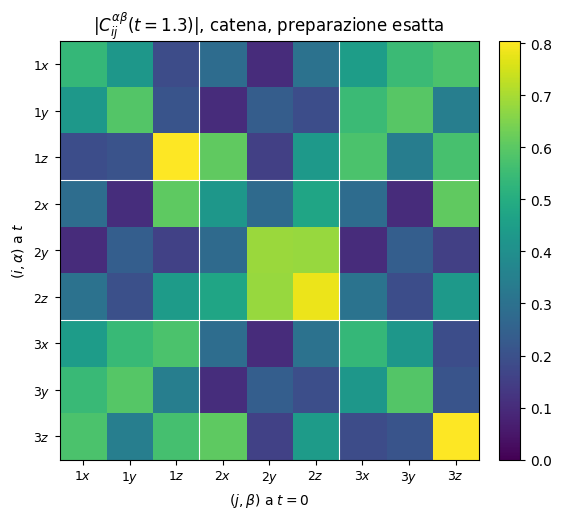

Nessun riquadro rosso: nessuno zero strutturale predetto per la catena


In [4]:
idx = {lab: k for k, lab in enumerate(labels)}
n = len(labels)
M = np.zeros((n, n), dtype=complex)
for row in rows:
    M[idx[f"{row['i']}{row['al']}"], idx[f"{row['j']}{row['be']}"]] = row['c_sv']

fig, ax = plt.subplots(figsize=(6, 5.3))
im = ax.imshow(np.abs(M), cmap='viridis', vmin=0, vmax=np.abs(M).max())
ax.set_xticks(range(n)); ax.set_yticks(range(n))
pretty = [f"${lab[0]}{lab[1]}$" for lab in labels]
ax.set_xticklabels(pretty, fontsize=9); ax.set_yticklabels(pretty, fontsize=9)
ax.set_xlabel(r'$(j,\beta)$ a $t=0$'); ax.set_ylabel(r'$(i,\alpha)$ a $t$')
ax.set_title(r'$|C_{ij}^{\alpha\beta}(t{=}1.3)|$, catena, preparazione esatta')
for k in (2.5, 5.5):
    ax.axhline(k, color='white', lw=0.8); ax.axvline(k, color='white', lw=0.8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()
print("Nessun riquadro rosso: nessuno zero strutturale predetto per la catena")

## 4. Vista d'insieme nel tempo (griglia $9\times9$)

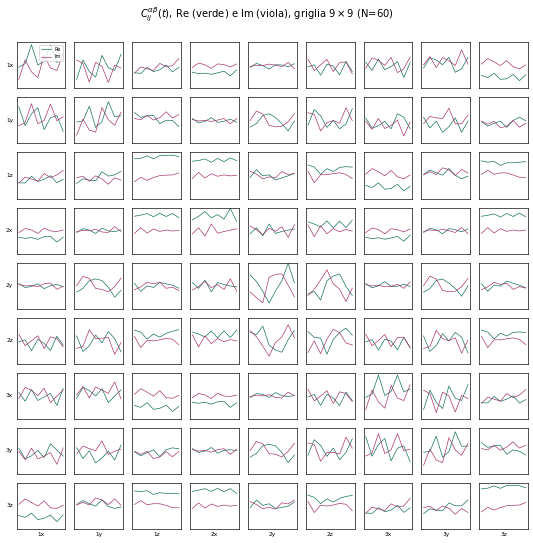

In [5]:
t_grid = np.linspace(0.3, 10, 8)
fig, axes = plt.subplots(9, 9, figsize=(9, 9), dpi=60, sharex=True)
for r, (i, al) in enumerate(itertools.product(sites, comps)):
    for c, (j, be) in enumerate(itertools.product(sites, comps)):
        vals = [correlator_from_circuit(i, al, j, be, t, 60, J, b, D, psi0) for t in t_grid]
        ax = axes[r, c]
        ax.plot(t_grid, [v.real for v in vals], lw=0.8, color='#0F6E56', label='Re')
        ax.plot(t_grid, [v.imag for v in vals], lw=0.8, color='#A4306B', label='Im')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_ylim(-1, 1)
for r, (i, al) in enumerate(itertools.product(sites, comps)):
    axes[r, 0].set_ylabel(f"{i}{al}", fontsize=7, rotation=0, ha='right', va='center')
for c, (j, be) in enumerate(itertools.product(sites, comps)):
    axes[-1, c].set_xlabel(f"{j}{be}", fontsize=7)
axes[0, 0].legend(fontsize=6, loc='upper right')
fig.suptitle(r"$C_{ij}^{\alpha\beta}(t)$, Re (verde) e Im (viola), griglia $9\times9$ (N=60)", y=1.0)
fig.tight_layout()
plt.show()

**Lettura della griglia.** Nessuna riga/colonna appare "piatta a zero" (a differenza dell'anello, dove la riga/colonna del sito 3 mostrava i quattro pannelli strutturalmente nulli). A differenza dell'anello non c'è nemmeno un pannello quasi-costante: l'anello aveva $C_{33}^{zz}$ pressoché congelato (autocorrelazione quasi conservata sul sito apicale); qui nessun sito è protetto in questo modo (verificato in Sez. 6: escursione minima osservata $\approx0.20$, non piccola in assoluto). Sia parte reale sia immaginaria oscillano in tutti i pannelli.

## 5. Selettore per ispezione singola

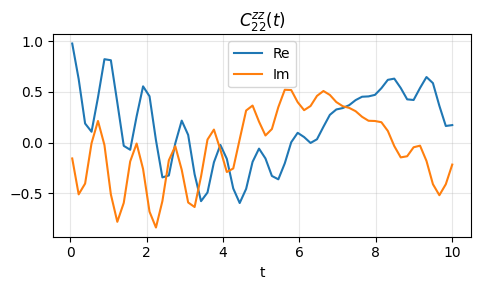

In [6]:
def plot_correlatore(i, alpha, j, beta, t_max=10, N=200):
    ts = np.linspace(0.05, t_max, 60)
    vals = [correlator_from_circuit(i, alpha, j, beta, t, N, J, b, D, psi0) for t in ts]
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(ts, [v.real for v in vals], label='Re')
    ax.plot(ts, [v.imag for v in vals], label='Im')
    ax.set_xlabel('t'); ax.set_title(f"$C_{{{i}{j}}}^{{{alpha}{beta}}}(t)$")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

plot_correlatore(2, "z", 2, "z")  # sito fisso, autocorrelazione zz

## 6. Analisi: escursione, simmetria, spettro

In [7]:
righe_an = []
for i, al in itertools.product(sites, comps):
    for j, be in itertools.product(sites, comps):
        ts = np.linspace(0.05, 10, 12)
        vals = [correlator_from_circuit(i, al, j, be, t, 60, J, b, D, psi0) for t in ts]
        re_vals = [v.real for v in vals]; im_vals = [v.imag for v in vals]
        righe_an.append(dict(i=i, al=al, j=j, be=be,
                              escursione_re=max(re_vals) - min(re_vals),
                              escursione_im=max(im_vals) - min(im_vals)))
df_an = pd.DataFrame(righe_an)
print("Correlatori con maggiore escursione (Re):")
print(df_an.sort_values('escursione_re', ascending=False).head(5)[['i','al','j','be','escursione_re']])
print()
print("Correlatori con MINORE escursione (i piu' vicini a costanti):")
print(df_an.sort_values('escursione_re').head(5)[['i','al','j','be','escursione_re','escursione_im']])
print()
print(f"Escursione minima osservata: {df_an['escursione_re'].min():.4f}")
print("-> nessun correlatore quasi-costante (a differenza di C_33^zz nell'anello, escursione ~0.0005):")
print("   coerente con l'assenza di un sito protetto dalla simmetria P13 nella catena.")

Correlatori con maggiore escursione (Re):
    i al  j be  escursione_re
70  3  y  3  y       1.513302
10  1  y  1  y       1.496636
50  2  z  2  z       1.475468
40  2  y  2  y       1.468476
64  3  y  1  y       1.441385

Correlatori con MINORE escursione (i piu' vicini a costanti):
    i al  j be  escursione_re  escursione_im
27  2  x  1  x       0.196444       0.276893
36  2  y  1  x       0.239575       0.230616
58  3  x  2  y       0.242594       0.257919
12  1  y  2  x       0.245762       0.253306
35  2  x  3  z       0.247003       0.170234

Escursione minima osservata: 0.1964
-> nessun correlatore quasi-costante (a differenza di C_33^zz nell'anello, escursione ~0.0005):
   coerente con l'assenza di un sito protetto dalla simmetria P13 nella catena.


### Relazione indotta da $P_{13}$: $C_{11}^{\alpha\beta}\equiv C_{33}^{\alpha\beta}$

In [8]:
maxdiff = 0.0
for al in comps:
    for be in comps:
        c11 = correlator_from_circuit(1, al, 1, be, 1.3, 200, J, b, D, psi0)
        c33 = correlator_from_circuit(3, al, 3, be, 1.3, 200, J, b, D, psi0)
        maxdiff = max(maxdiff, abs(c11 - c33))
print(f"max|C_11 - C_33| su tutte le 9 componenti (via circuito): {maxdiff:.2e}")
print("(entro l'errore di Trotter, coerente con lambda_alpha=+1 per ogni alpha)")

max|C_11 - C_33| su tutte le 9 componenti (via circuito): 3.56e-03
(entro l'errore di Trotter, coerente con lambda_alpha=+1 per ogni alpha)


### Lo spettro dietro due casi opposti

In [9]:
def pesi_spettrali(i, alpha, j, beta):
    Hm = H
    Ev, Vv = np.linalg.eigh(Hm)
    from validate_circuito_correlazioni_catena import site_op
    A = site_op(i, alpha); B = site_op(j, beta)
    ak = np.array([np.vdot(psi0, A @ Vv[:, k]) for k in range(8)])
    bk = np.array([np.vdot(Vv[:, k], B @ psi0) for k in range(8)])
    return np.abs(ak * bk)

w_ricco = pesi_spettrali(1, "y", 1, "y")
w_piatto = pesi_spettrali(2, "z", 2, "z")
print("pesi |a_k b_k| (8 autostati):")
print(f"  C_11^yy (ricco):  {np.round(w_ricco, 4)}  -> {np.sum(w_ricco > 0.05*w_ricco.max())} modi rilevanti")
print(f"  C_22^zz:          {np.round(w_piatto, 4)}  -> {np.sum(w_piatto > 0.05*w_piatto.max())} modi rilevanti")

pesi |a_k b_k| (8 autostati):
  C_11^yy (ricco):  [0.000e+00 1.665e-01 2.537e-01 3.807e-01 1.900e-03 1.675e-01 2.970e-02
 1.000e-04]  -> 5 modi rilevanti
  C_22^zz:          [0.1089 0.4444 0.     0.2251 0.2216 0.     0.     0.    ]  -> 4 modi rilevanti


**Discussione.** Il caso con più modi rilevanti mostra una dinamica più ricca
(più frequenze battute nel tempo); un caso con pochi modi appare più "piatto" o oscillante
in modo semplice.

## 7. Confronto con la validazione a shot finiti (risultati precomputati)

In [10]:
d = np.load("scan81_catena_vqedm_results.npz")
err_trotter_mean = float(d['err_trotter_mean'])
err_trotter_max = float(d['err_trotter_max'])
err_shot_mean = float(d['err_shot_mean'])
err_shot_max = float(d['err_shot_max'])
print(f"Errore Trotter (precomputato, scan81): media={err_trotter_mean:.2e} max={err_trotter_max:.2e}")
print(f"Errore statistico (shots, precomputato): media={err_shot_mean:.2e} max={err_shot_max:.2e}")
print(f"\nCoerente con quanto appena osservato in questo notebook (residuo medio {df['residuo'].mean():.2e})")

Errore Trotter (precomputato, scan81): media=1.76e-03 max=3.34e-03
Errore statistico (shots, precomputato): media=1.39e-02 max=3.85e-02

Coerente con quanto appena osservato in questo notebook (residuo medio 1.76e-03)


## 8. Riepilogo

- Tutte le 81 combinazioni misurate via circuito effettivo, nessuna collassa a zero.
- Griglia temporale, spettro e relazione $P_{13}$ confermano quanto stabilito nel documento
  di simmetria.
- Confronto con lo scan precomputato (statevector + shot) coerente.

Prossimo passo: `circuito_correlazioni_trimero_catena_vqe.ipynb` (stessa analisi con
preparazione VQE reale, ansatz W-2qC.K2).